<a href="https://colab.research.google.com/github/Nihar783/qwen-multimodal-captioning/blob/main/Qwen_2_5VL_image_video_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qwen-vl-utils
!pip install -q -U bitsandbytes
!pip install -q -U git+https://github.com/huggingface/transformers.git
!pip install -q -U git+https://github.com/huggingface/peft.git
!pip install -q -U git+https://github.com/huggingface/accelerate.git
!pip install --upgrade transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 92.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.3.0.dev0
    Uninstalling transformers-5.3.0.dev0:
      Successfully uninstalled transformers-5.3.0.dev0


In [2]:
!pip install decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 43.0 MB/s eta 0:00:00


In [3]:
import os #files and pathways
import random # lightweight randomness
import io # image buffers
import requests #HTTPS requests for downloading assets
import textwrap #nicely format long text displays

import numpy as np
import torch #tensor library and GPU acceleration

from transformers import (
    Qwen2_5_VLForConditionalGeneration, #Multimodal LLM
    AutoProcessor,
    BitsAndBytesConfig #for quantization of llm
)

from PIL import Image #Load/Save/Manipulate images

import matplotlib.pyplot as plt #Plotting
import matplotlib.patches as patches #Bounding Box overlays(draw images using matplotlib)

from qwen_vl_utils import process_vision_info #Post-process qwn outputs
import decord

import IPython.display as ipd #inline display

In [4]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=bnb_config
    )

processor = AutoProcessor.from_pretrained(model_id,
                                          trust_remote_code=True)

print(f"Model loaded on: {model.device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded on: cuda:0


In [7]:
path = "/content/IMG-20251020-WA0032.jpg"

ext = os.path.splitext(path)[1].lower()
image_ext = [".jpg", ".jpeg", ".png"]
video_ext = [".mp4"]

if ext in image_ext:
  img = Image.open(path)
elif ext in video_ext:
  vr = decord.VideoReader(path)
  frames_indices = [int(i * len(vr) / 8) for i in range(8)]
  frames = [vr[i].asnumpy() for i in frames_indices]
  pil_frames = [Image.fromarray(frame) for frame in frames]

In [11]:
content = []

if ext in image_ext:
  content.append({"type": "image", "image": img})
elif ext in video_ext:
  content.append({"type": "video", "video": pil_frames})
content.append({"type": "text", "text": "Describe the content."})

msg = [
    {"role": "user",
     "content": content
     }
]

In [12]:
text_prompt = processor.apply_chat_template(
    msg,
    tokenize=False,
    add_generation_prompt=True
)
print(text_prompt)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe the content.<|im_end|>
<|im_start|>assistant



In [13]:
image_inputs, video_inputs = process_vision_info(msg)

In [14]:
input = processor(
    text=[text_prompt],
    images=image_inputs,
    videos=video_inputs,
    return_tensors="pt",
    padding=True
).to(model.device)

with torch.no_grad():
  generate_ids = model.generate(
      **input,
      max_new_tokens = 128
  )
  print("Generated IDs shape:", generate_ids.shape)

Generated IDs shape: torch.Size([1, 1935])


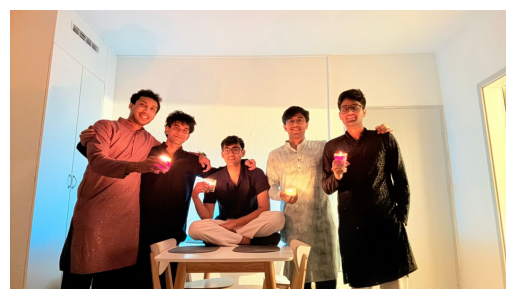

The image shows five young men standing together in a room with a modern,
minimalist design. They are all smiling and appear to be celebrating or
participating in a cultural event. Each man is holding a lit candle in a small
holder, which is illuminated by the candlelight. The background features a white
wall with a large mirror and some furniture, including a small table and chairs.
The overall atmosphere suggests a festive or ceremonial occasion. done


In [16]:
caption = processor.batch_decode(
    generate_ids[:, input.input_ids.shape[-1]:],
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

if ext in image_ext:
  plt.imshow(img)

elif ext in video_ext:
  num_frames = len(frames)
  plt.figure(figsize = (15,3))
  for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i])

plt.axis("off")
plt.show()

width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption, "done")